# GO:BP Coverage Plots: CLAMPfull vs CLAMPbase

💡 **Environment:** `clamp-analyses`

Reads the per-coverage RDS files from `00_bp_ora_analysis.ipynb`, applies FDR filtering, computes coverage, and plots:

Plot order per FDR section:
1. **Broad biological pathways** (GO:BP Level 3): CLAMPfull, CLAMPbase
2. **Pathway coverage** (GO:BP exact terms): CLAMPfull, CLAMPbase

In [44]:
library(here)
library(ggplot2)
library(dplyr)
library(GO.db)

input_dir <- here("output/03_model_biology/00_archs4/00_pathway_coverage_bp/00_bp_ora_analysis")

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title        = element_text(size = 24, colour = "black"),
      axis.title.y      = element_text(margin = margin(r = 18)),
      axis.text         = element_text(size = 18, colour = "black"),
      axis.line         = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks        = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor   = element_blank(),
      legend.position    = "none",
      plot.title         = element_text(size = 22, face = "bold", colour = "black",
                                        margin = margin(b = 10)),
      strip.background   = element_blank(),
      strip.text         = element_text(face = "bold", size = 18),
      plot.margin        = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

## Load RDS files and compute coverage

In [45]:
coverage_pcts  <- c(1, 5, 10, 25, 50, 75, 100)
fdr_thresholds <- c(0.05, 0.01)

level3_terms <- unique(unlist(lapply(
  Filter(Negate(is.na), as.character(GOBPCHILDREN[["GO:0008150"]])),
  function(l2) Filter(Negate(is.na), as.character(GOBPCHILDREN[[l2]]))
)))
message(sprintf("Level 3 GO:BP terms: %d", length(level3_terms)))

compute_coverage_df <- function(model_type, rds_subdir) {
  rows <- lapply(coverage_pcts, function(pct) {
    rds_path <- file.path(rds_subdir, sprintf("pct%d.rds", pct))
    if (!file.exists(rds_path)) {
      message(sprintf("Missing: %s pct%d", model_type, pct))
      return(NULL)
    }
    rds <- readRDS(rds_path)

    # build level3 ancestor map for all unique terms in this coverage level
    all_ids <- unique(rds$ora_df$ID)
    level3_ancestors <- setNames(
      lapply(all_ids, function(t) {
        anc <- tryCatch(as.character(GOBPANCESTOR[[t]]), error = function(e) character(0))
        intersect(anc, level3_terms)
      }),
      all_ids
    )

    # Level 3 terms represented in the ORA background (denominator for coverage_level3)
    n_level3_in_ora <- length(unique(unlist(level3_ancestors)))

    lapply(unique(rds$meta$seed), function(s) {
      seed_df  <- rds$ora_df[rds$ora_df$seed == s, ]
      meta_row <- rds$meta[rds$meta$seed == s, ]

      lapply(fdr_thresholds, function(fdr) {
        sig_terms  <- unique(seed_df$ID[seed_df$p.adjust < fdr])
        sig_level3 <- unique(unlist(level3_ancestors[sig_terms]))

        data.frame(
          model_type      = model_type,
          coverage_pct    = pct,
          seed            = s,
          fdr             = fdr,
          n_samples       = meta_row$n_samples,
          n_lvs           = meta_row$n_lvs,
          coverage_bp     = length(sig_terms)  / rds$n_total_bp,
          coverage_level3 = length(sig_level3) / n_level3_in_ora,
          stringsAsFactors = FALSE
        )
      })
    })
  })
  # use base:: to avoid BiocGenerics masking do.call / Filter / rbind
  flat <- base::Filter(Negate(is.null), rows)
  if (length(flat) == 0) return(NULL)
  flat <- unlist(flat, recursive = FALSE)
  flat <- unlist(flat, recursive = FALSE)
  base::do.call(base::rbind, flat)
}

df_full <- compute_coverage_df("CLAMPfull", file.path(input_dir, "CLAMPfull"))
df_base <- compute_coverage_df("CLAMPbase", file.path(input_dir, "CLAMPbase"))

if (is.null(df_full) || nrow(df_full) == 0) stop("CLAMPfull data not found. Run 00_bp_ora_analysis.ipynb first.")

message("CLAMPfull: ", nrow(df_full), " rows")
if (!is.null(df_base) && nrow(df_base) > 0) {
  message("CLAMPbase: ", nrow(df_base), " rows (coverage levels: ",
          paste(sort(unique(df_base$coverage_pct)), collapse = ", "), "%)")
} else {
  message("CLAMPbase: no data yet")
  df_base <- NULL
}

Level 3 GO:BP terms: 476

Missing: CLAMPfull pct25

Missing: CLAMPfull pct50

Missing: CLAMPfull pct75

Missing: CLAMPfull pct100

Missing: CLAMPbase pct1

Missing: CLAMPbase pct5

Missing: CLAMPbase pct10

Missing: CLAMPbase pct25

Missing: CLAMPbase pct50

Missing: CLAMPbase pct75

Missing: CLAMPbase pct100

CLAMPfull: 18 rows

CLAMPbase: no data yet



## Build coverage labels and split by FDR

In [46]:
head(df_full)

,model_type,coverage_pct,seed,fdr,n_samples,n_lvs,coverage_bp,coverage_level3
,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,CLAMPfull,1,1,0.05,6056,128,0.8025174,0.9424779
2,CLAMPfull,1,1,0.01,6056,128,0.6667801,0.8849558
3,CLAMPfull,1,2,0.05,6056,128,0.8004763,0.9601770
4,CLAMPfull,1,2,0.01,6056,128,0.6492601,0.9026549
5,CLAMPfull,1,3,0.05,6056,130,0.7997959,0.9557522
6,CLAMPfull,1,3,0.01,6056,130,0.6412655,0.9115044


In [47]:
# sample-count label map from CLAMPfull FDR 0.05
sample_counts <- df_full %>%
  dplyr::filter(fdr == 0.05, seed == 1) %>%
  dplyr::select(coverage_pct, n_samples) %>%
  dplyr::arrange(coverage_pct)

label_map <- setNames(
  paste0(format(sample_counts$n_samples, big.mark = ","),
         " samples (", sample_counts$coverage_pct, "%)"),
  sample_counts$coverage_pct
)

add_labels <- function(df) {
  df %>% dplyr::mutate(
    coverage_label  = factor(label_map[as.character(coverage_pct)], levels = label_map),
    coverage_bp_pct     = coverage_bp     * 100,
    coverage_level3_pct = coverage_level3 * 100
  )
}

df_full <- add_labels(df_full)
if (!is.null(df_base)) df_base <- add_labels(df_base)

# split by FDR
full_05 <- df_full %>% dplyr::filter(fdr == 0.05)
full_01 <- df_full %>% dplyr::filter(fdr == 0.01)
base_05 <- if (!is.null(df_base)) df_base %>% dplyr::filter(fdr == 0.05) else NULL
base_01 <- if (!is.null(df_base)) df_base %>% dplyr::filter(fdr == 0.01) else NULL

## Plot helper

In [48]:
make_coverage_plot <- function(df, y_col, title, label_offset = 2) {
  purple_fill <- "#9b59b6"

  label_df <- df %>%
    dplyr::group_by(coverage_label) %>%
    dplyr::summarise(
      mean_y  = mean(.data[[y_col]], na.rm = TRUE),
      max_y   = max(.data[[y_col]],  na.rm = TRUE),
      label_y = max_y + label_offset,
      label   = sprintf("%.1f%%", mean_y),
      .groups = "drop"
    )

  ggplot(df, aes(x = coverage_label, y = .data[[y_col]])) +
    geom_boxplot(
      width = 0.55, fill = scales::alpha(purple_fill, 0.80),
      colour = "black", linewidth = 0.8, outlier.shape = NA
    ) +
    geom_jitter(
      width = 0.08, size = 2.8, shape = 21,
      fill = "white", colour = "#2b2b2b", stroke = 0.5, alpha = 0.95
    ) +
    stat_summary(
      fun = mean, geom = "point", shape = 23, size = 3.8,
      fill = "white", colour = "black", stroke = 0.8
    ) +
    geom_text(
      data = label_df,
      aes(x = coverage_label, y = label_y, label = label),
      inherit.aes = FALSE, size = 5.5, fontface = "bold", vjust = 0
    ) +
    scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.22))) +
    labs(x = "Proportion of samples",
         y = "GO:BP ORA pathway coverage (%)",
         title = title) +
    coord_cartesian(clip = "off") +
    theme_ng() +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1))
}

## FDR < 0.05

### Broad biological pathways: Level 3

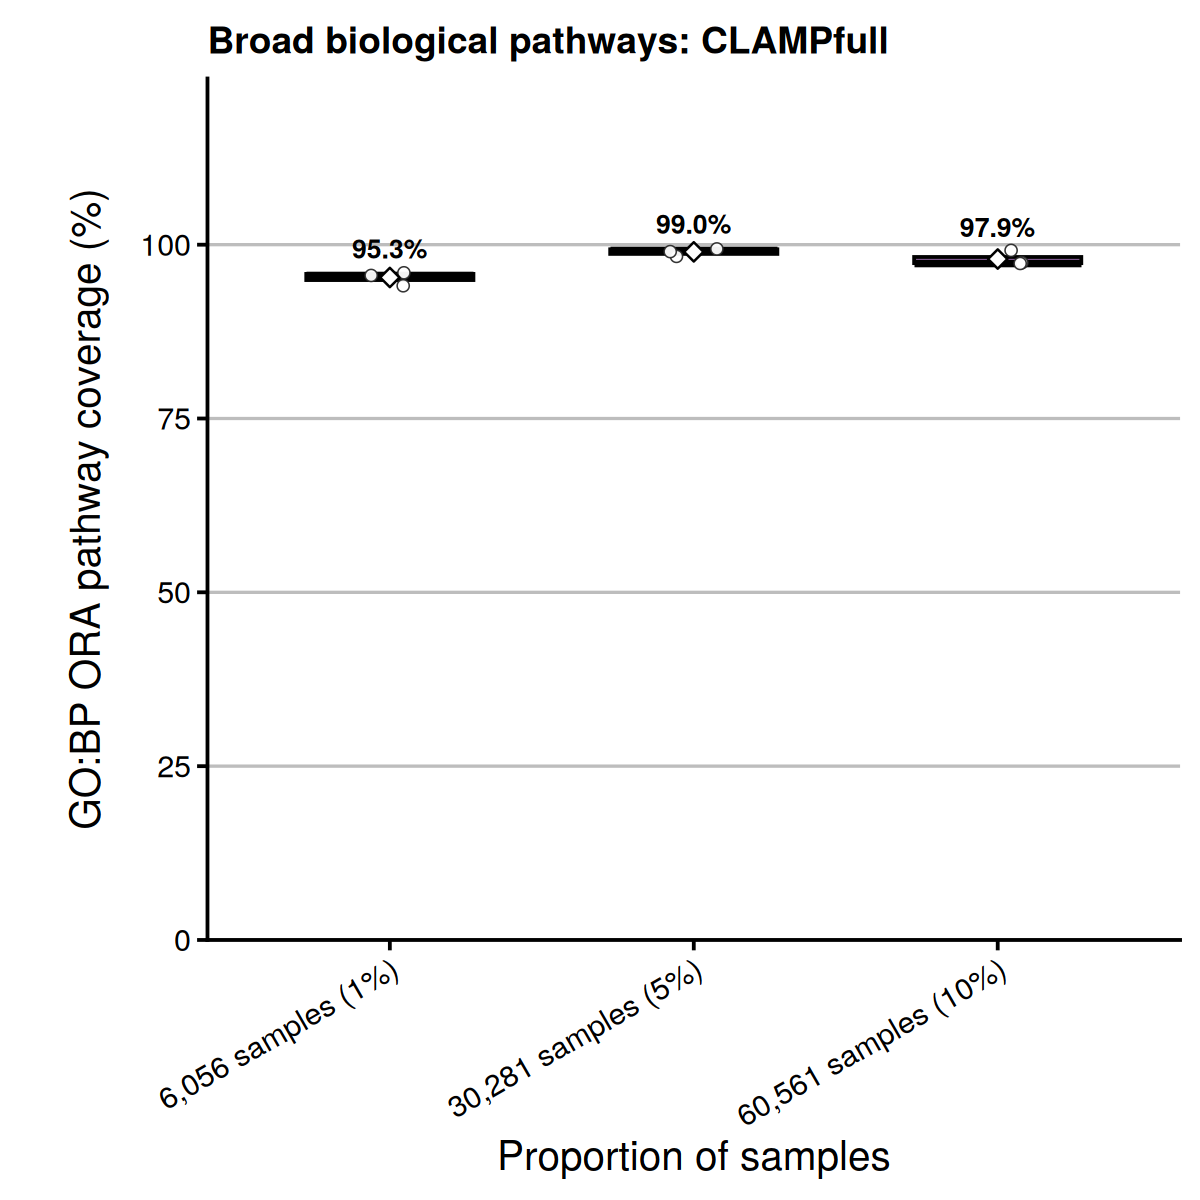

In [49]:
options(repr.plot.width = 10, repr.plot.height = 10)
make_coverage_plot(full_05, "coverage_level3_pct", "Broad biological pathways: CLAMPfull")

In [50]:
if (is.null(base_05)) { message("CLAMPbase not available yet.") } else {
  print(make_coverage_plot(base_05, "coverage_level3_pct", "Broad biological pathways: CLAMPbase"))
}

CLAMPbase not available yet.



### Pathway coverage: exact GO:BP terms

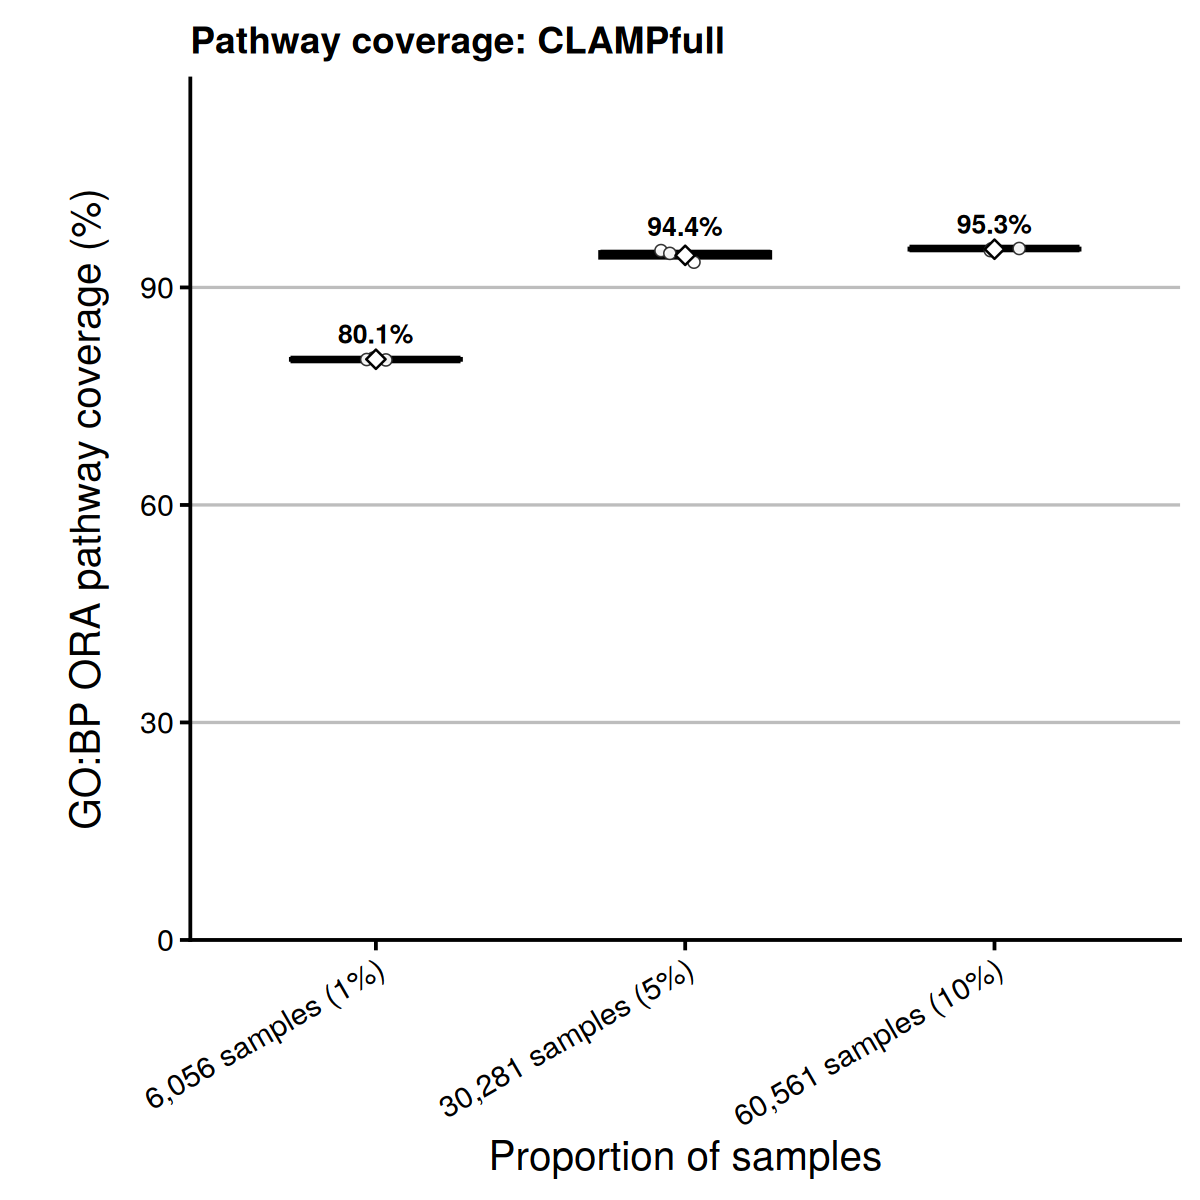

In [51]:
make_coverage_plot(full_05, "coverage_bp_pct", "Pathway coverage: CLAMPfull")

In [52]:
if (is.null(base_05)) { message("CLAMPbase not available yet.") } else {
  print(make_coverage_plot(base_05, "coverage_bp_pct", "Pathway coverage: CLAMPbase"))
}

CLAMPbase not available yet.



## FDR < 0.01

### Broad biological pathways: Level 3

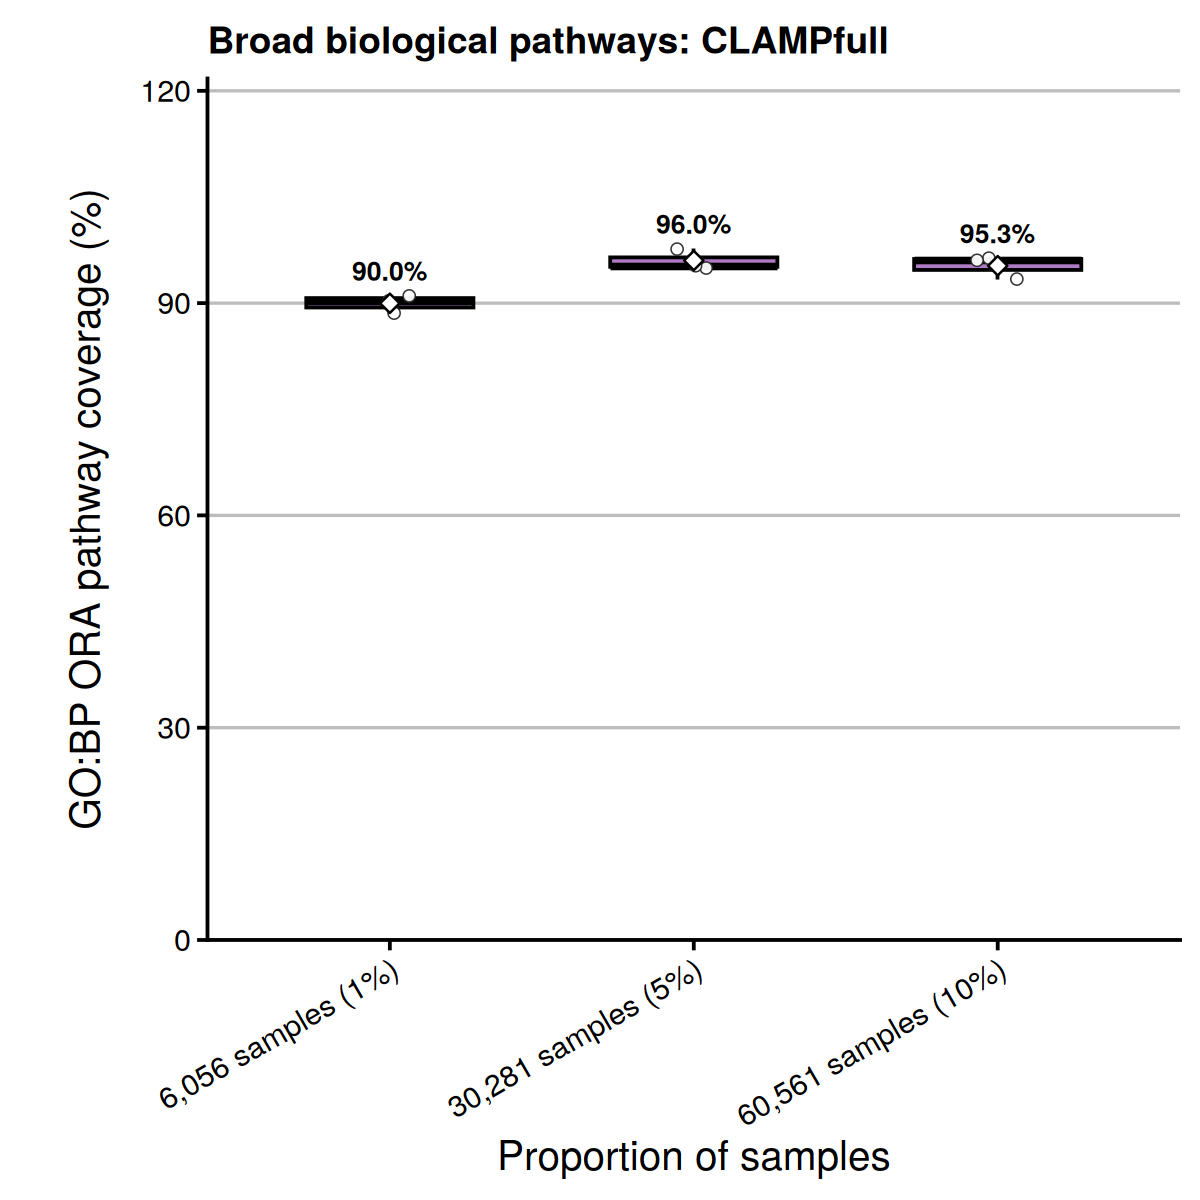

In [53]:
make_coverage_plot(full_01, "coverage_level3_pct", "Broad biological pathways: CLAMPfull")

In [54]:
if (is.null(base_01)) { message("CLAMPbase not available yet.") } else {
  print(make_coverage_plot(base_01, "coverage_level3_pct", "Broad biological pathways: CLAMPbase"))
}

CLAMPbase not available yet.



### Pathway coverage: exact GO:BP terms

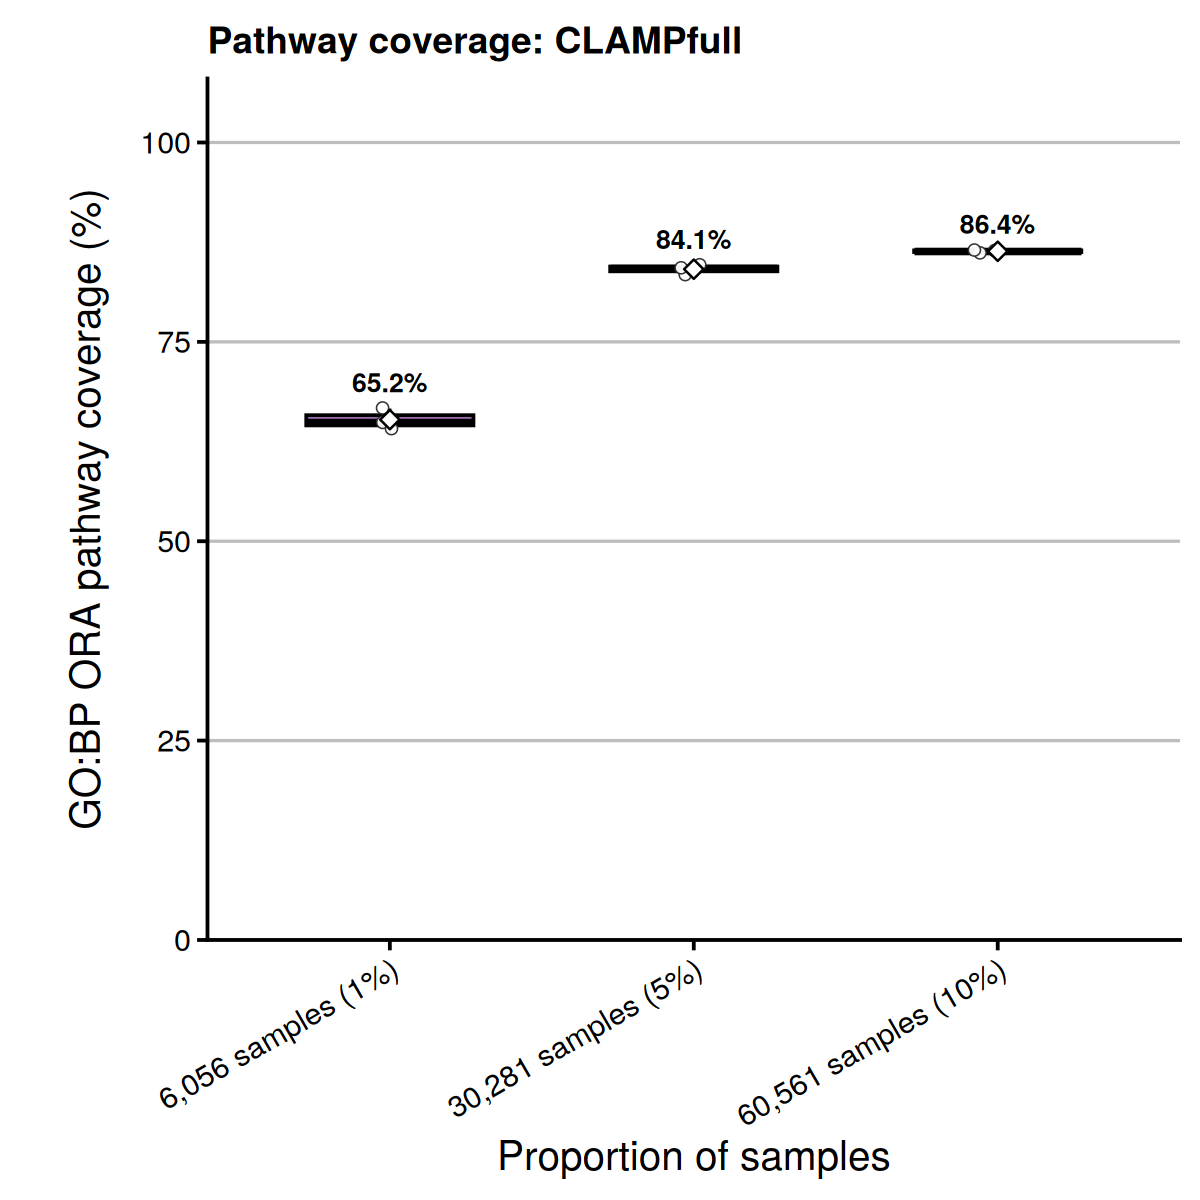

In [55]:
make_coverage_plot(full_01, "coverage_bp_pct", "Pathway coverage: CLAMPfull")

In [56]:
if (is.null(base_01)) { message("CLAMPbase not available yet.") } else {
  print(make_coverage_plot(base_01, "coverage_bp_pct", "Pathway coverage: CLAMPbase"))
}

CLAMPbase not available yet.

